# Actor-Critic: learn online with continuous actions

Vanilla Actor-Critic combines a stochastic **actor** $\pi_\theta(a\mid s)$ with a **critic** $V_\phi(s)$. After every transition, the critic constructs the one-step TD target

$$y_t=r_{t+1}+\gamma(1-d_t)V_\phi(s_{t+1}),$$

and the TD error $\delta_t=y_t-V_\phi(s_t)$ trains the critic and acts as the actor's advantage estimate. This notebook keeps that online structure and replaces the discrete policy with a bounded Gaussian policy for `Pendulum-v1`.


In [1]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn

ENV_ID = "Pendulum-v1"
TOTAL_TIMESTEPS = 30_000
ACTOR_LEARNING_RATE = 1e-3
CRITIC_LEARNING_RATE = 1e-3
GAMMA = 0.99
MAX_GRAD_NORM = 1.0

# Tiny networks and per-step updates are faster on the CPU than on a GPU.
device = torch.device("cpu")
env = gym.make(ENV_ID)
observation_dim = int(np.prod(env.observation_space.shape))
action_dim = int(np.prod(env.action_space.shape))
observation_scale = torch.as_tensor(
    env.observation_space.high, dtype=torch.float32, device=device
)
action_low = torch.as_tensor(env.action_space.low, device=device)
action_high = torch.as_tensor(env.action_space.high, device=device)
action_scale = (action_high - action_low) / 2
action_bias = (action_high + action_low) / 2
print(f"Observation size: {observation_dim}; actions: {action_dim}; device: {device}")


Observation size: 3; actions: 1; device: cpu


## 1. Build separate actor and critic networks

The actor predicts a Gaussian mean and learns one log standard deviation per action. A `tanh` transform followed by rescaling keeps samples inside the environment's `Box` bounds. The critic predicts one scalar $V_\phi(s)$.

Pendulum's angular velocity has a much larger range than its other observations. Dividing by the known observation bounds gives every network input a comparable scale. A second small hidden layer improves the nonlinear policy while keeping both networks easy to read.


In [2]:
def preprocess(observations):
    observations = torch.as_tensor(
        observations, dtype=torch.float32, device=device
    )
    return observations / observation_scale


def make_network(output_dim):
    return nn.Sequential(
        nn.Linear(observation_dim, 64),
        nn.Tanh(),
        nn.Linear(64, 64),
        nn.Tanh(),
        nn.Linear(64, output_dim),
    ).to(device)


actor = make_network(output_dim=action_dim)
critic = make_network(output_dim=1)
log_std = nn.Parameter(torch.full((action_dim,), -0.5, device=device))
actor_optimizer = torch.optim.Adam(
    [*actor.parameters(), log_std], lr=ACTOR_LEARNING_RATE
)
critic_optimizer = torch.optim.Adam(
    critic.parameters(), lr=CRITIC_LEARNING_RATE
)


def action_distribution(observations):
    mean = actor(preprocess(observations))
    return torch.distributions.Normal(mean, log_std.clamp(-5, 2).exp())


def squash(raw_actions):
    return action_bias + action_scale * torch.tanh(raw_actions)


def log_probability(distribution, raw_actions):
    correction = torch.log(
        action_scale * (1 - torch.tanh(raw_actions).square()) + 1e-6
    )
    return (distribution.log_prob(raw_actions) - correction).sum(dim=-1)


def select_action(observation, deterministic=False):
    with torch.no_grad():
        distribution = action_distribution(np.atleast_2d(observation))
        raw_action = (
            distribution.mean if deterministic else distribution.sample()
        )
        action = squash(raw_action)
    return action.squeeze(0).cpu().numpy(), raw_action.squeeze(0).cpu().numpy()


## 2. Update from one transition

For a sampled transition $(s_t,a_t,r_{t+1},s_{t+1})$, the critic minimizes $\tfrac12(V_\phi(s_t)-y_t)^2$. The actor minimizes

$$L_{\text{actor}}=-\operatorname{stopgrad}(\delta_t)\log \pi_\theta(a_t\mid s_t).$$

A positive TD error makes the sampled action more probable; a negative error makes it less probable. True terminations stop bootstrapping, while time-limit truncations still bootstrap from the final observation. Gradient clipping limits rare large updates without changing the algorithm.


In [3]:
def update(observation, raw_action, reward, next_observation, terminated):
    observation = np.atleast_2d(observation)
    next_observation = np.atleast_2d(next_observation)

    value = critic(preprocess(observation)).squeeze()
    with torch.no_grad():
        next_value = critic(preprocess(next_observation)).squeeze()
        td_target = reward + GAMMA * (1.0 - float(terminated)) * next_value
    td_error = (td_target - value).detach()

    distribution = action_distribution(observation)
    raw_action = torch.as_tensor(
        np.atleast_2d(raw_action), dtype=torch.float32, device=device
    )
    actor_loss = -log_probability(distribution, raw_action).squeeze() * td_error
    critic_loss = 0.5 * (value - td_target).square()

    actor_optimizer.zero_grad()
    actor_loss.backward()
    torch.nn.utils.clip_grad_norm_(
        [*actor.parameters(), log_std], MAX_GRAD_NORM
    )
    actor_optimizer.step()

    critic_optimizer.zero_grad()
    critic_loss.backward()
    torch.nn.utils.clip_grad_norm_(critic.parameters(), MAX_GRAD_NORM)
    critic_optimizer.step()

    return {
        "actor_loss": actor_loss.item(),
        "critic_loss": critic_loss.item(),
        "td_error": td_error.item(),
    }


## 3. Learn online

Sample one action, take one environment step, and immediately update the actor and critic from that transition. Each transition is used exactly once by the policy that generated it.


In [4]:
def train(total_timesteps):
    episode_returns, metrics = [], []
    episode_return = 0.0
    observation, _ = env.reset()

    for step in range(1, total_timesteps + 1):
        action, raw_action = select_action(observation)
        next_observation, reward, terminated, truncated, _ = env.step(action)
        metrics.append(
            update(
                observation,
                raw_action,
                reward,
                next_observation,
                terminated,
            )
        )
        episode_return += reward

        if terminated or truncated:
            episode_returns.append(episode_return)
            episode_return = 0.0
            observation, _ = env.reset()
        else:
            observation = next_observation

        print(
            f"\rStep {step}/{total_timesteps} | "
            f"Episodes: {len(episode_returns)} | "
            f"Episode return: {episode_return:.1f}",
            end="",
        )

    env.close()
    return episode_returns, metrics


episode_returns, metrics = train(TOTAL_TIMESTEPS)
print(f"\nTrained for {len(episode_returns)} completed episodes.")


/home/pablo/workspace/AprendeRL/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:484: UserWarning: Found GPU0 NVIDIA GeForce GTX 960M which is of compute capability (CC) 5.0.
The following list shows the CCs this version of PyTorch was built for and the hardware CCs it supports:
- 7.5 which supports hardware CC >=7.5,<8.0
- 8.0 which supports hardware CC >=8.0,<9.0 except {8.7}
- 8.6 which supports hardware CC >=8.6,<9.0 except {8.7}
- 9.0 which supports hardware CC >=9.0,<10.0
- 10.0 which supports hardware CC >=10.0,<11.0 except {10.1}
- 12.0 which supports hardware CC >=12.0,<13.0
Your installed torch==2.14.0+cu130 does not include kernels for this GPU. Reinstall the same version against a CUDA build that does, e.g.:
  For CUDA 12.6 use pip install torch==2.14.0 --index-url https://download.pytorch.org/whl/cu126
  _warn_unsupported_code(d, device_cc, code_ccs)
/home/pablo/workspace/AprendeRL/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:602: UserWarning: 
NVIDIA

Step 53/30000 | Episodes: 0 | Episode return: -347.5

Step 108/30000 | Episodes: 0 | Episode return: -692.4

Step 163/30000 | Episodes: 0 | Episode return: -1074.2

Step 208/30000 | Episodes: 1 | Episode return: -2.4

...

Step 29786/30000 | Episodes: 148 | Episode return: -1474.4

Step 29842/30000 | Episodes: 149 | Episode return: -313.0

Step 29896/30000 | Episodes: 149 | Episode return: -665.0

Step 29952/30000 | Episodes: 149 | Episode return: -1094.6

Step 30000/30000 | Episodes: 150 | Episode return: 0.0
Trained for 150 completed episodes.


## 4. Inspect learning

Episode return measures performance. Losses and TD errors need not decrease monotonically because the changing policy changes the data distribution. Smoothed curves make their scale and trend easier to inspect.


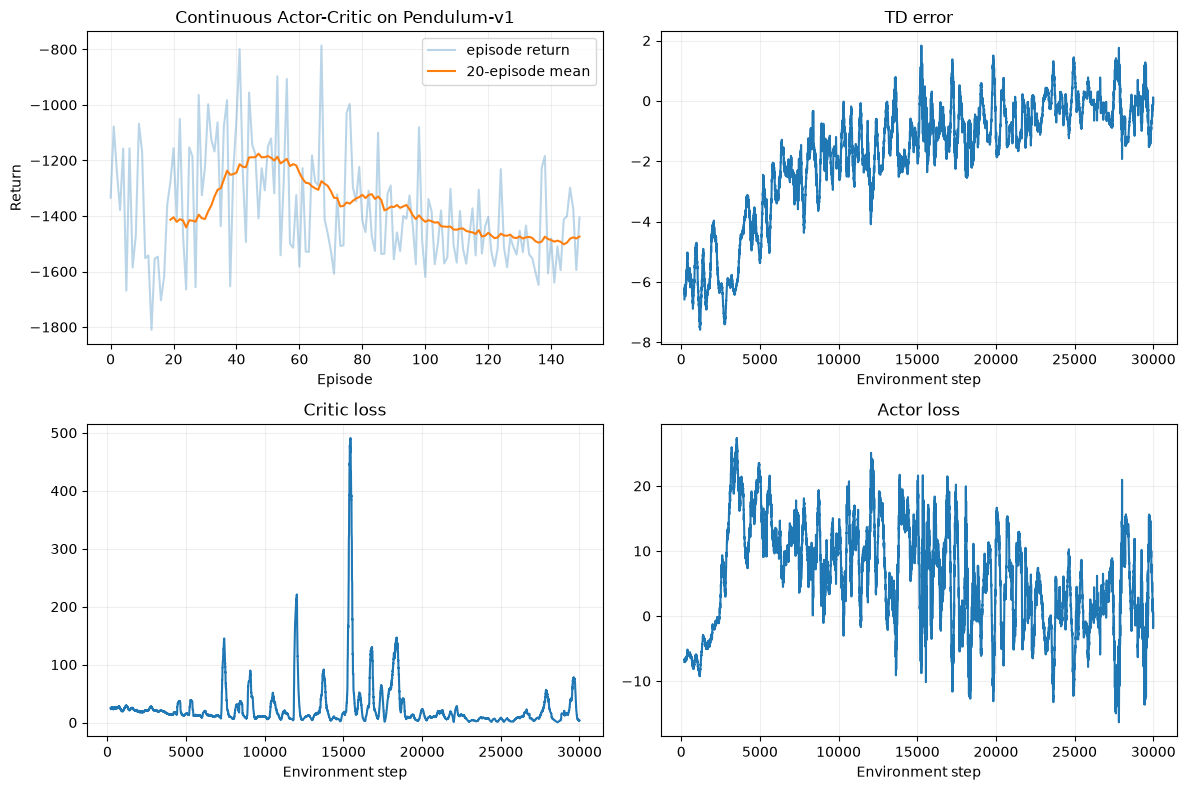

In [5]:
def moving_average(values, window):
    values = np.asarray(values)
    window = min(window, len(values))
    return np.convolve(values, np.ones(window) / window, mode="valid")


returns = np.asarray(episode_returns)
return_window = min(20, len(returns))
update_window = min(200, len(metrics))
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()
axes[0].plot(returns, alpha=0.3, label="episode return")
axes[0].plot(
    np.arange(return_window - 1, len(returns)),
    moving_average(returns, return_window),
    label=f"{return_window}-episode mean",
)
axes[0].set(
    title=f"Continuous Actor-Critic on {ENV_ID}",
    xlabel="Episode",
    ylabel="Return",
)
axes[0].legend()
for axis, key, title in zip(
    axes[1:],
    ["td_error", "critic_loss", "actor_loss"],
    ["TD error", "Critic loss", "Actor loss"],
    strict=True,
):
    values = [item[key] for item in metrics]
    axis.plot(
        np.arange(update_window - 1, len(values)),
        moving_average(values, update_window),
    )
    axis.set(title=title, xlabel="Environment step")
for axis in axes:
    axis.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## 5. Evaluate the modal policy

Training samples actions. Evaluation squashes the Gaussian mean and uses a separate environment, so it is deterministic and cannot disturb training state.


In [6]:
env = gym.make(ENV_ID, render_mode="human")
episode_returns = []

for episode in range(5):
    observation, _ = env.reset()
    episode_return = 0.0
    for step in range(1000):
        action, _ = select_action(observation, deterministic=True)
        observation, reward, terminated, truncated, _ = env.step(action)
        episode_return += reward
        print(
            f"Episode {episode + 1}: step={step + 1}, "
            f"return={episode_return:.1f}",
            end="\r",
        )
        if terminated or truncated:
            break
    episode_returns.append(episode_return)
    print()

env.close()
print(f"Mean return: {np.mean(episode_returns):.1f} +/- {np.std(episode_returns):.1f}")


Episode 1: step=200, return=-1440.9


Episode 2: step=200, return=-1272.3


Episode 3: step=200, return=-1537.8


Episode 4: step=200, return=-1576.2


Episode 5: step=200, return=-1326.6
Mean return: -1430.8 +/- 117.2
